# Classification

## Goals
Contrast regression and classification, and see why linear regression is a poor fit for classification problems.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Classification Problems

Classification problems have a limited set of possible outcomes - like spam/not spam, or malignant/benign. Binary classification means there are exactly two outcomes, usually labeled 0 (negative) and 1 (positive).

In plots, 'X' typically marks positive examples, 'O' marks negative examples.

Simple example data - x_train/y_train for a single feature, X_train2/y_train2 for two features.

In [7]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0, 0, 0, 1, 1, 1])
X_train2 = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train2 = np.array([0, 0, 0, 1, 1, 1])

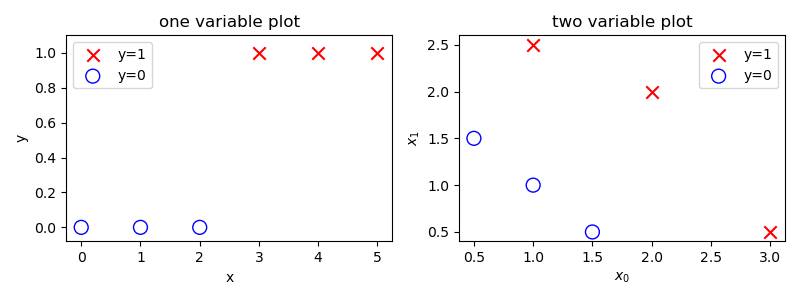

In [8]:
pos = y_train == 1
neg = y_train == 0

fig, ax = plt.subplots(1, 2, figsize=(8, 3))

ax[0].scatter(x_train[pos], y_train[pos], marker='x', s=80, c='red', label="y=1")
ax[0].scatter(x_train[neg], y_train[neg], marker='o', s=100, facecolors='none', edgecolors='blue', label="y=0")
ax[0].set_ylim(-0.08, 1.1)
ax[0].set_ylabel('y')
ax[0].set_xlabel('x')
ax[0].set_title('one variable plot')
ax[0].legend()

pos2 = y_train2 == 1
neg2 = y_train2 == 0
ax[1].scatter(X_train2[pos2, 0], X_train2[pos2, 1], marker='x', s=80, c='red', label="y=1")
ax[1].scatter(X_train2[neg2, 0], X_train2[neg2, 1], marker='o', s=100, facecolors='none', edgecolors='blue', label="y=0")
ax[1].set_xlabel('$x_0$')
ax[1].set_ylabel('$x_1$')
ax[1].set_title('two variable plot')
ax[1].legend()

plt.tight_layout()
plt.savefig("classification_data.png")
plt.close()

from IPython.display import Image
Image("classification_data.png")

## Linear Regression approach

Let's try applying linear regression to this classification problem, using tumor size to predict malignant (1) vs benign (0), and see why it doesn't work well.

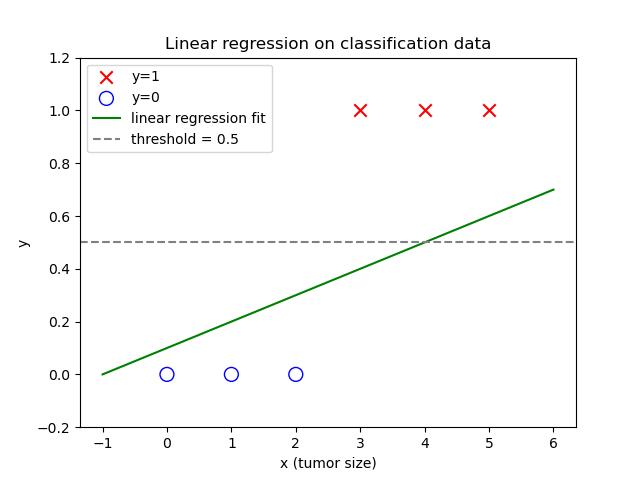

In [10]:
# Our 6 training points - x is a feature (e.g. tumor size), y is the class label (0 or 1)
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0, 0, 0, 1, 1, 1])

# Hand-picked weight and bias, just to draw an example straight line (not trained)
w, b = 0.1, 0.1

# 100 evenly spaced x-values, used to draw a smooth line instead of just 6 points
x_line = np.linspace(-1, 6, 100)

# Apply the linear regression formula across that smooth range
y_line = w * x_line + b

# Start a fresh blank plot
plt.figure()

# Boolean filters: True where the label is 1, and True where the label is 0
pos = y_train == 1
neg = y_train == 0

# Plot the category-1 points as red X's, using the filter to pick only those points
plt.scatter(x_train[pos], y_train[pos], marker='x', s=80, c='red', label="y=1")

# Plot the category-0 points as hollow blue circles
plt.scatter(x_train[neg], y_train[neg], marker='o', s=100, facecolors='none', edgecolors='blue', label="y=0")

# Draw the straight-line linear regression fit across the smooth x range
plt.plot(x_line, y_line, c='green', label="linear regression fit")

# Draw a dashed horizontal line at 0.5 - a possible decision threshold
plt.axhline(0.5, color='gray', linestyle='--', label="threshold = 0.5")

# Give the y-axis a bit of padding above 1 and below 0 so nothing is cut off
plt.ylim(-0.2, 1.2)

# Label the axes and add a title
plt.xlabel('x (tumor size)')
plt.ylabel('y')
plt.legend()
plt.title('Linear regression on classification data')

# Save the chart to a file, then close the plotting session
plt.savefig("linear_vs_classification.png")
plt.close()

# Load and display the saved image directly in the notebook
from IPython.display import Image
Image("linear_vs_classification.png")